# Modelo YOLO — prueba local

Este notebook utiliza el modelo ya entrenado para verificar una imagen externa.

Flujo:

```text
pegar URL de una imagen
→ detectar el Sudoku
→ mostrar la detección
→ mostrar el tablero recortado
```


## 1. Importar librerías

In [1]:
import cv2
import numpy as np
import requests

from io import BytesIO
from PIL import Image
from IPython.display import display
from ultralytics import YOLO


## 2. Cargar el modelo entrenado

In [2]:

modelo = YOLO("../modelo_yolo/modelo/best.pt")

print("Modelo YOLO cargado correctamente")


Modelo YOLO cargado correctamente


## 3. Evaluar el modelo

In [3]:
ruta_yaml = (
    "../modelo_yolo/data.yaml"
)

metricas_val = modelo.val(
    data=ruta_yaml,
    split="val"
)

metricas_test = modelo.val(
    data=ruta_yaml,
    split="test"
)

print("Evaluación completada")

Ultralytics 8.4.70  Python-3.12.10 torch-2.12.0+cpu CPU (AMD Ryzen 7 7730U with Radeon Graphics)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 262.8231.6 MB/s, size: 43.5 KB)
val: Scanning C:\Users\Dario\Documents\Caperta_Botcamp\Apuntes_Juan\4-DeepLearning\6-DL_Project\DL_sudoku\modelo_yolo\img_proc\labels\val.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.1s6.7s
                   all         21         21      0.998          1      0.995       0.99
Speed: 1.3ms preprocess, 122.8ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\Dario\Documents\Caperta_Botcamp\Apuntes_Juan\4-DeepLearning\6-DL_Project\DL_sudoku\modelo_yolo\runs\detect\val-3
Ultralytics 8.4.70  Python-3.12.10 torch-2.12.0+cpu CPU (AMD Ryzen 7 7730U with Radeon

## 4. Resultados de la evaluación

In [4]:
print("VALIDACIÓN")
print(
    "Precision:",
    round(metricas_val.box.mp, 4)
)
print(
    "Recall:",
    round(metricas_val.box.mr, 4)
)
print(
    "mAP50:",
    round(metricas_val.box.map50, 4)
)
print(
    "mAP50-95:",
    round(metricas_val.box.map, 4)
)

print("\nTEST")
print(
    "Precision:",
    round(metricas_test.box.mp, 4)
)
print(
    "Recall:",
    round(metricas_test.box.mr, 4)
)
print(
    "mAP50:",
    round(metricas_test.box.map50, 4)
)
print(
    "mAP50-95:",
    round(metricas_test.box.map, 4)
)

VALIDACIÓN
Precision: 0.9977
Recall: 1.0
mAP50: 0.995
mAP50-95: 0.9901

TEST
Precision: 0.9561
Recall: 1.0
mAP50: 0.995
mAP50-95: 0.9728


## 5. Introducir la URL o ruta de una imagen

Imagen cargada correctamente


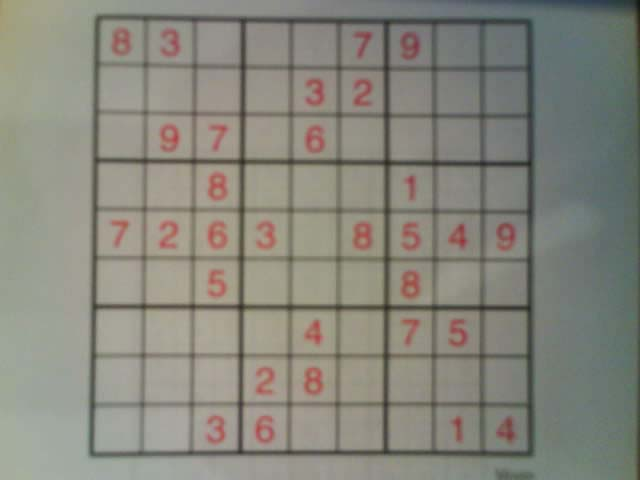

In [5]:
ruta_imagen = input(
    "Pega la URL o la ruta local de la imagen: "
).strip()

if ruta_imagen.startswith(
    ("http://", "https://")
):

    respuesta = requests.get(
        ruta_imagen,
        timeout=30
    )

    respuesta.raise_for_status()

    imagen_pil = Image.open(
        BytesIO(respuesta.content)
    ).convert("RGB")

    imagen = cv2.cvtColor(
        np.array(imagen_pil),
        cv2.COLOR_RGB2BGR
    )

else:

    imagen = cv2.imread(
        ruta_imagen
    )

    if imagen is None:
        raise ValueError(
            "No se ha podido cargar la imagen. "
            "Comprueba la ruta."
        )

    imagen_pil = Image.fromarray(
        cv2.cvtColor(
            imagen,
            cv2.COLOR_BGR2RGB
        )
    )

print("Imagen cargada correctamente")

display(imagen_pil)

## 6. Detectar el Sudoku

In [6]:
resultados = modelo.predict(
    source=imagen,
    conf=0.25,
    save=False,
    verbose=False
)

resultado = resultados[0]

if len(resultado.boxes) == 0:
    raise ValueError(
        "No se ha detectado ningún Sudoku."
    )

indice = int(
    resultado.boxes.conf.argmax().item()
)

confianza = float(
    resultado.boxes.conf[indice].item()
)

print(
    f"Sudoku detectado con "
    f"{confianza:.2%} de confianza"
)

Sudoku detectado con 99.39% de confianza


## 7. Mostrar la detección

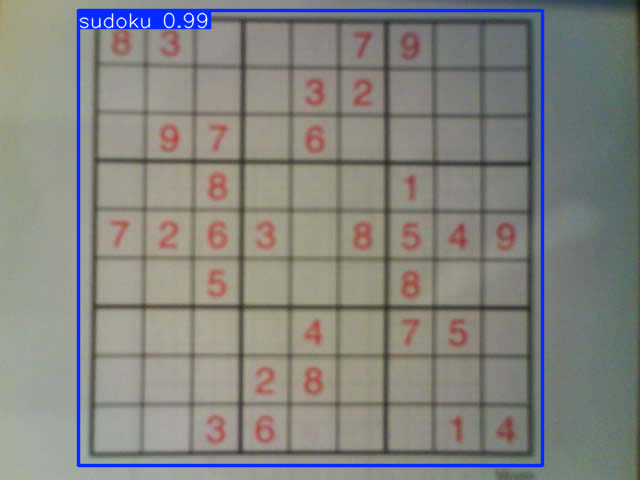

In [7]:
imagen_anotada = resultado.plot()

imagen_anotada = cv2.cvtColor(
    imagen_anotada,
    cv2.COLOR_BGR2RGB
)

display(
    Image.fromarray(
        imagen_anotada
    )
)

## 8. Mostrar el tablero recortado

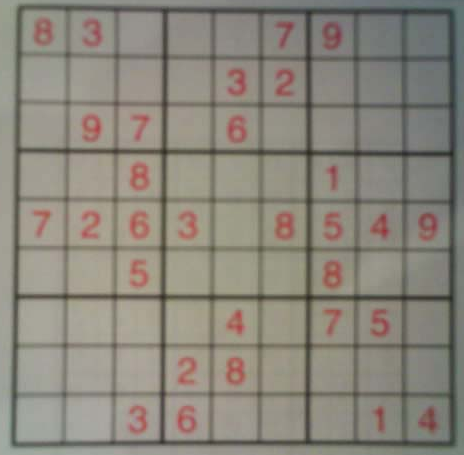

In [8]:
x1, y1, x2, y2 = (
    resultado.boxes.xyxy[indice]
    .cpu()
    .numpy()
    .astype(int)
)

tablero = imagen[
    y1:y2,
    x1:x2
]

tablero_rgb = cv2.cvtColor(
    tablero,
    cv2.COLOR_BGR2RGB
)

display(
    Image.fromarray(
        tablero_rgb
    )
)